
# Hierarchical Clustering

Notebook này giúp bạn học **Hierarchical Clustering** trong **Unsupervised Learning**.

## Mục tiêu bài học

Sau notebook này, bạn cần hiểu được:

1. Hierarchical Clustering là gì.
2. Dendrogram là gì và dùng để làm gì.
3. Agglomerative Clustering hoạt động như thế nào.
4. Các loại linkage: single, complete, average, ward.
5. Cách chọn số cụm bằng dendrogram.
6. Cách demo thuật toán bằng Python.
7. So sánh Hierarchical Clustering với K-means.



## 1. Hierarchical Clustering là gì?

**Hierarchical Clustering** là thuật toán phân cụm dữ liệu bằng cách xây dựng một cấu trúc phân cấp giữa các điểm dữ liệu.

Nói dễ hiểu:

> Thuật toán sẽ xem điểm nào gần nhau trước, nhóm chúng lại, sau đó tiếp tục nhóm các cụm gần nhau hơn để tạo thành một cây phân cấp.

Cây phân cấp này gọi là **dendrogram**.

Khác với **K-means**, Hierarchical Clustering không bắt buộc phải chọn số cụm ngay từ đầu. Ta có thể nhìn vào dendrogram rồi quyết định nên chia dữ liệu thành bao nhiêu cụm.



## 2. Có mấy loại Hierarchical Clustering?

Có 2 loại chính:

### 2.1. Agglomerative Clustering

Đây là cách phổ biến nhất.

Quy trình:

```text
Ban đầu: mỗi điểm dữ liệu là một cụm riêng
Sau đó: gộp 2 cụm gần nhau nhất
Lặp lại: cho đến khi tất cả điểm nằm trong một cụm lớn
```

Agglomerative đi từ:

```text
Nhỏ → Lớn
```

Ví dụ:

```text
A | B | C | D | E

AB | C | D | E

AB | CD | E

ABCD | E

ABCDE
```

### 2.2. Divisive Clustering

Cách này ít phổ biến hơn.

Quy trình:

```text
Ban đầu: tất cả điểm nằm trong một cụm lớn
Sau đó: tách dần thành các cụm nhỏ hơn
```

Divisive đi từ:

```text
Lớn → Nhỏ
```

Trong thực tế, khi nói đến Hierarchical Clustering trong Python, ta thường dùng **Agglomerative Clustering**.



## 3. Dendrogram là gì?

**Dendrogram** là biểu đồ dạng cây dùng để biểu diễn quá trình gộp cụm.

Ví dụ:

```text
A và B gần nhau → gộp lại thành cụm AB
C và D gần nhau → gộp lại thành cụm CD
Sau đó AB và CD tiếp tục được gộp lại
```

Dendrogram có thể nhìn như sau:

```text
        ABCD
       /    \
     AB      CD
    /  \    /  \
   A    B  C    D
```

Ý nghĩa quan trọng:

- Trục dọc thường biểu diễn **khoảng cách** hoặc **mức độ khác biệt** giữa các cụm.
- Hai cụm được gộp ở vị trí càng thấp thì chúng càng giống nhau.
- Hai cụm được gộp ở vị trí càng cao thì chúng càng khác nhau.
- Ta có thể “cắt” dendrogram ở một độ cao nào đó để chọn số cụm.



## 4. Công thức khoảng cách Euclidean Distance

Hierarchical Clustering cần đo khoảng cách giữa các điểm dữ liệu.

Một công thức phổ biến là **Euclidean Distance**:

$$
d(A, B) = \sqrt{(x_A - x_B)^2 + (y_A - y_B)^2}
$$

Trong đó:

- $A$ và $B$ là hai điểm dữ liệu.
- $x_A, y_A$ là toạ độ của điểm $A$.
- $x_B, y_B$ là toạ độ của điểm $B$.
- $d(A, B)$ là khoảng cách giữa $A$ và $B$.

Nếu $d(A, B)$ nhỏ, nghĩa là hai điểm gần nhau.

Nếu $d(A, B)$ lớn, nghĩa là hai điểm xa nhau.



## 5. Linkage Method là gì?

Khi đã có cụm, ta cần biết:

> Khoảng cách giữa cụm này và cụm kia là bao nhiêu?

Cách tính khoảng cách giữa hai cụm gọi là **linkage method**.

Có 4 loại linkage quan trọng:

1. Single linkage
2. Complete linkage
3. Average linkage
4. Ward linkage



## 6. Single Linkage

**Single linkage** lấy khoảng cách nhỏ nhất giữa hai cụm.

Công thức:

$$
d(A, B) = \min(d(a, b))
$$

Trong đó:

- $A$ và $B$ là hai cụm.
- $a$ là một điểm trong cụm $A$.
- $b$ là một điểm trong cụm $B$.
- Ta lấy cặp điểm gần nhau nhất giữa hai cụm.

Hiểu đơn giản:

> Chỉ cần có một điểm của cụm A gần một điểm của cụm B, thuật toán sẽ xem hai cụm này gần nhau.

Ưu điểm:

- Có thể phát hiện cụm có hình dạng dài hoặc cong.

Nhược điểm:

- Dễ bị **chaining effect**.
- Nghĩa là nhiều điểm có thể bị nối thành một chuỗi dài, làm cụm bị loang.



## 7. Complete Linkage

**Complete linkage** lấy khoảng cách lớn nhất giữa hai cụm.

Công thức:

$$
d(A, B) = \max(d(a, b))
$$

Hiểu đơn giản:

> Hai cụm chỉ được xem là gần nhau nếu kể cả hai điểm xa nhất giữa chúng cũng không quá xa.

Ưu điểm:

- Tạo cụm chặt chẽ hơn.
- Ít bị chaining effect hơn single linkage.

Nhược điểm:

- Có thể nhạy với outlier.



## 8. Average Linkage

**Average linkage** lấy khoảng cách trung bình giữa tất cả các cặp điểm trong hai cụm.

Công thức:

$$
d(A, B) = \frac{1}{|A||B|} \sum_{a \in A} \sum_{b \in B} d(a, b)
$$

Hiểu đơn giản:

> Thay vì chỉ nhìn điểm gần nhất hoặc xa nhất, average linkage nhìn trung bình toàn bộ khoảng cách giữa hai cụm.

Ưu điểm:

- Cân bằng hơn single linkage và complete linkage.
- Thường là lựa chọn an toàn nếu chưa biết nên dùng loại nào.

Nhược điểm:

- Có thể chậm hơn khi dữ liệu lớn.



## 9. Ward Linkage

**Ward linkage** không chỉ đo khoảng cách trực tiếp. Nó gộp cụm sao cho sự tăng phương sai trong cụm là nhỏ nhất.

Hiểu đơn giản:

> Ward cố gắng tạo ra các cụm gọn, chặt và không bị loang quá nhiều.

Ý tưởng:

$$
\text{Choose merge that minimizes increase in within-cluster variance}
$$

Ưu điểm:

- Tạo cụm khá đẹp và compact.
- Thường dùng tốt với dữ liệu dạng số.
- Kết quả có cảm giác giống K-means.

Nhược điểm:

- Thường đi cùng Euclidean distance.
- Không phù hợp với mọi loại khoảng cách.



## 10. So sánh nhanh các linkage

| Linkage | Cách tính | Ưu điểm | Nhược điểm |
|---|---|---|---|
| Single | Khoảng cách gần nhất | Tốt với cụm dài/cong | Dễ bị chaining effect |
| Complete | Khoảng cách xa nhất | Cụm chặt hơn | Nhạy với outlier |
| Average | Khoảng cách trung bình | Cân bằng | Có thể chậm hơn |
| Ward | Giảm tăng variance trong cụm | Cụm gọn, đẹp | Thường dùng với Euclidean |



## 11. Cài đặt thư viện

Các thư viện cần dùng:

- `pandas`: xử lý dữ liệu dạng bảng.
- `numpy`: tính toán số học.
- `matplotlib`: vẽ biểu đồ.
- `scikit-learn`: dùng mô hình clustering.
- `scipy`: vẽ dendrogram.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage



## 12. Demo 1: Dữ liệu khách hàng đơn giản

Giả sử ta có dữ liệu khách hàng gồm:

- `spending`: số tiền chi tiêu.
- `frequency`: tần suất mua hàng.

Mục tiêu:

> Dùng Hierarchical Clustering để chia khách hàng thành các nhóm có hành vi giống nhau.


In [2]:

data = pd.DataFrame({
    "customer": ["A", "B", "C", "D", "E", "F", "G", "H"],
    "spending": [10, 12, 11, 80, 85, 78, 200, 210],
    "frequency": [2, 3, 2, 10, 11, 9, 1, 2]
})

data


,customer,spending,frequency
0,A,10,2
1,B,12,3
2,C,11,2
3,D,80,10
4,E,85,11
5,F,78,9
6,G,200,1
7,H,210,2



## 13. Visualize dữ liệu ban đầu

Trước khi clustering, ta nên nhìn dữ liệu bằng biểu đồ scatter plot.


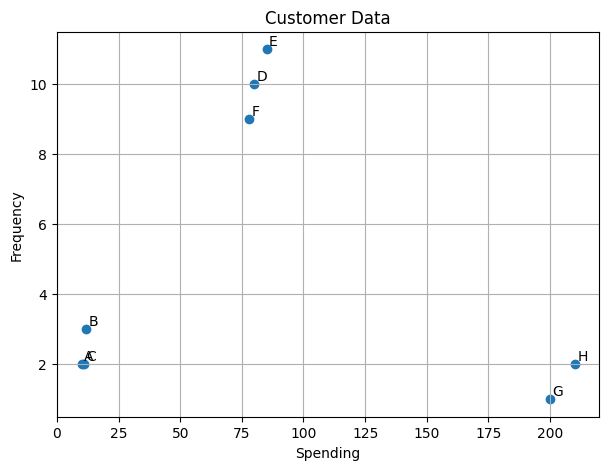

In [3]:

plt.figure(figsize=(7, 5))
plt.scatter(data["spending"], data["frequency"])

for i, row in data.iterrows():
    plt.text(row["spending"] + 1, row["frequency"] + 0.1, row["customer"])

plt.title("Customer Data")
plt.xlabel("Spending")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()



Nhìn bằng mắt thường, có thể thấy:

```text
A, B, C khá gần nhau
D, E, F khá gần nhau
G, H khá gần nhau nhưng khác nhóm còn lại
```

Vậy có khả năng dữ liệu có khoảng **3 cụm**.



## 14. Scale dữ liệu

Vì `spending` và `frequency` có đơn vị và độ lớn khác nhau, ta cần chuẩn hoá dữ liệu trước khi clustering.

Nếu không scale, feature có giá trị lớn hơn sẽ ảnh hưởng mạnh hơn đến khoảng cách.

Ví dụ:

```text
spending: 10 đến 210
frequency: 1 đến 11
```

`spending` lớn hơn nhiều nên có thể lấn át `frequency`.


In [4]:

features = data[["spending", "frequency"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

X_scaled_df = pd.DataFrame(X_scaled, columns=["spending_scaled", "frequency_scaled"])
X_scaled_df


,spending_scaled,frequency_scaled
0,-1.006101,-0.762001
1,-0.979537,-0.508001
2,-0.992819,-0.762001
3,-0.076371,1.270001
4,-0.009961,1.524002
5,-0.102934,1.016001
6,1.517452,-1.016001
7,1.650271,-0.762001



## 15. Vẽ dendrogram

Dendrogram giúp ta xem quá trình gộp cụm.

Ở đây ta dùng **Ward linkage**.


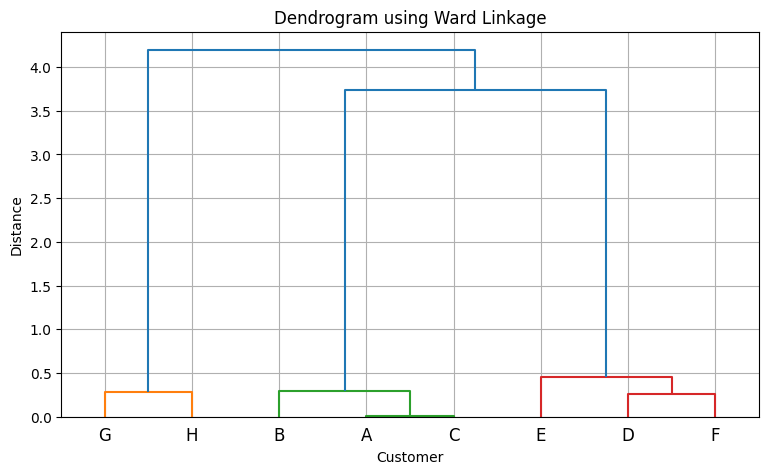

In [5]:

linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(9, 5))
dendrogram(linked, labels=data["customer"].values)
plt.title("Dendrogram using Ward Linkage")
plt.xlabel("Customer")
plt.ylabel("Distance")
plt.grid(True)
plt.show()



## 16. Cách đọc dendrogram

Khi nhìn dendrogram, ta chú ý:

1. Hai điểm/cụm nào được gộp thấp thì chúng giống nhau.
2. Hai điểm/cụm nào chỉ gộp ở độ cao lớn thì chúng khác nhau nhiều.
3. Ta chọn số cụm bằng cách cắt ngang dendrogram ở vị trí có khoảng trống dọc lớn.

Trong ví dụ này, dữ liệu có thể chia thành **3 cụm**:

```text
Cluster 1: A, B, C
Cluster 2: D, E, F
Cluster 3: G, H
```



## 17. Train Agglomerative Clustering

Sau khi quan sát dendrogram, ta chọn:

```python
n_clusters = 3
```


In [6]:

model = AgglomerativeClustering(n_clusters=3, linkage="ward")
data["cluster"] = model.fit_predict(X_scaled)

data


,customer,spending,frequency,cluster
0,A,10,2,2
1,B,12,3,2
2,C,11,2,2
3,D,80,10,0
4,E,85,11,0
5,F,78,9,0
6,G,200,1,1
7,H,210,2,1



## 18. Visualize kết quả clustering


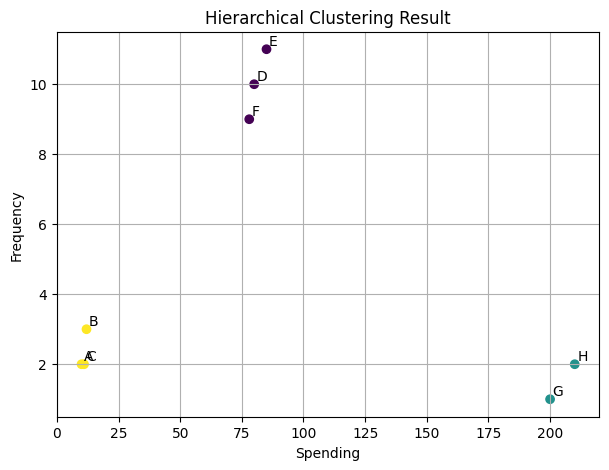

In [7]:

plt.figure(figsize=(7, 5))
scatter = plt.scatter(data["spending"], data["frequency"], c=data["cluster"])

for i, row in data.iterrows():
    plt.text(row["spending"] + 1, row["frequency"] + 0.1, row["customer"])

plt.title("Hierarchical Clustering Result")
plt.xlabel("Spending")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()



## 19. Giải thích kết quả

Kết quả có thể chia khách hàng thành 3 nhóm:

### Nhóm 1

Khách hàng có mức chi tiêu thấp và tần suất thấp.

Ví dụ:

```text
A, B, C
```

### Nhóm 2

Khách hàng có mức chi tiêu trung bình/cao và tần suất mua cao.

Ví dụ:

```text
D, E, F
```

### Nhóm 3

Khách hàng có mức chi tiêu rất cao nhưng tần suất thấp.

Ví dụ:

```text
G, H
```

Ý nghĩa kinh doanh:

- Nhóm A/B/C có thể là khách hàng mới hoặc ít tương tác.
- Nhóm D/E/F có thể là khách hàng trung thành.
- Nhóm G/H có thể là khách hàng chi tiêu lớn nhưng mua không thường xuyên.



## 20. Demo 2: So sánh các linkage

Bây giờ ta thử vẽ dendrogram với nhiều linkage khác nhau:

- single
- complete
- average
- ward

Mục tiêu:

> Xem cách linkage khác nhau làm thay đổi quá trình gộp cụm.


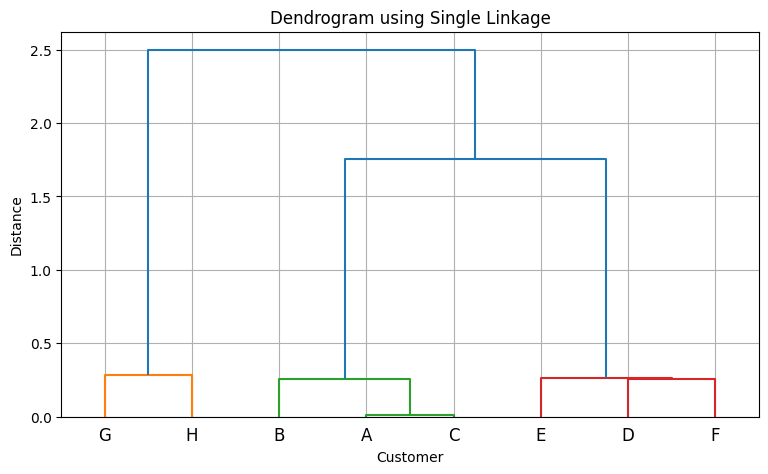

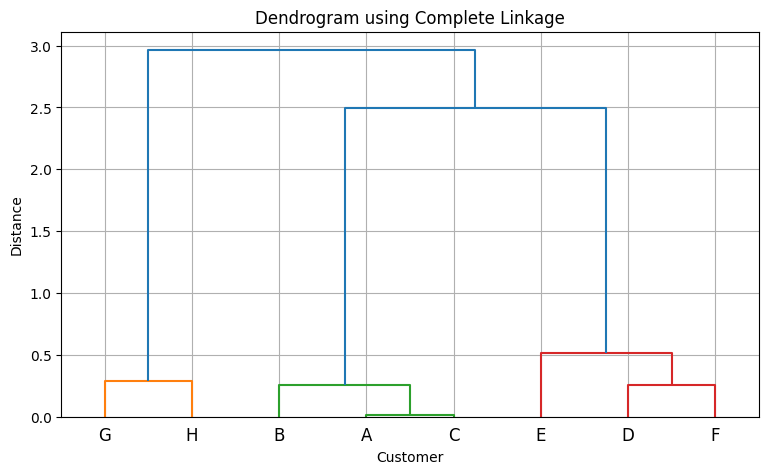

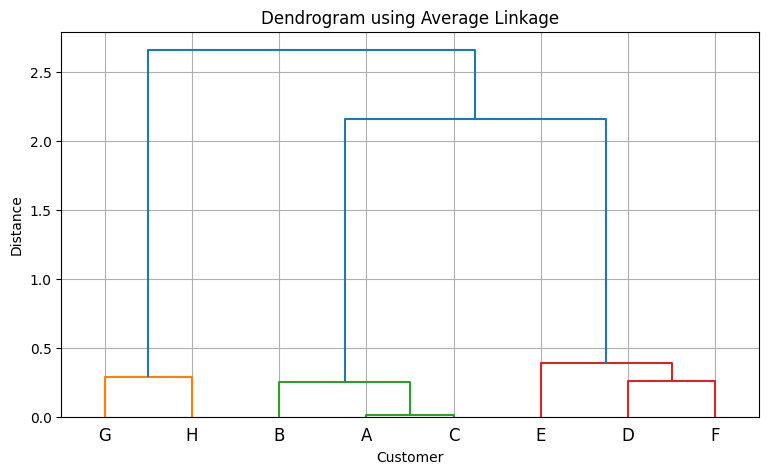

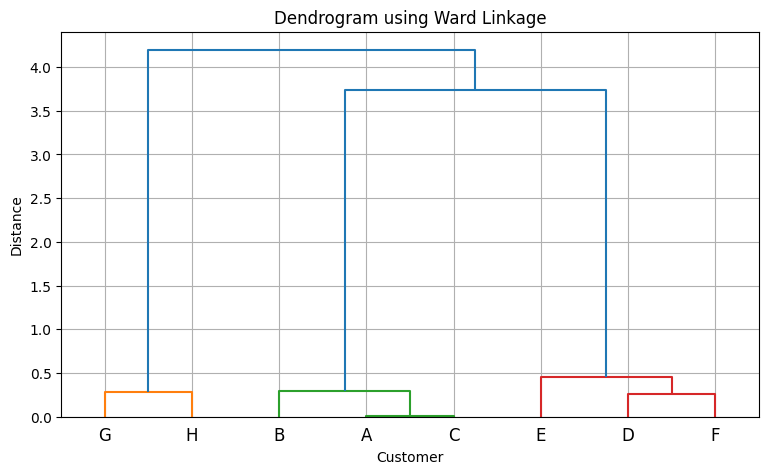

In [8]:

linkage_methods = ["single", "complete", "average", "ward"]

for method in linkage_methods:
    linked = linkage(X_scaled, method=method)

    plt.figure(figsize=(9, 5))
    dendrogram(linked, labels=data["customer"].values)
    plt.title(f"Dendrogram using {method.capitalize()} Linkage")
    plt.xlabel("Customer")
    plt.ylabel("Distance")
    plt.grid(True)
    plt.show()



## 21. Nhận xét về linkage

### Single linkage

Có thể nối các điểm theo chuỗi. Nếu dữ liệu có nhiều điểm trung gian, cụm có thể bị kéo dài.

### Complete linkage

Tạo cụm chặt hơn vì nó xét khoảng cách xa nhất giữa hai cụm.

### Average linkage

Cân bằng giữa single và complete.

### Ward linkage

Thường tạo cụm gọn và dễ giải thích, đặc biệt với dữ liệu số đã scale.



## 22. Demo 3: Dữ liệu nhiều điểm hơn

Ta tạo một bộ dữ liệu lớn hơn bằng `make_blobs`.


In [9]:

from sklearn.datasets import make_blobs

X, true_labels = make_blobs(
    n_samples=100,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

blob_data = pd.DataFrame(X, columns=["feature_1", "feature_2"])
blob_data.head()


,feature_1,feature_2
0,-9.685121,5.808676
1,-6.066110,-8.110974
2,-2.978672,9.556846
3,-5.476833,-8.281961
4,-8.480540,7.884307


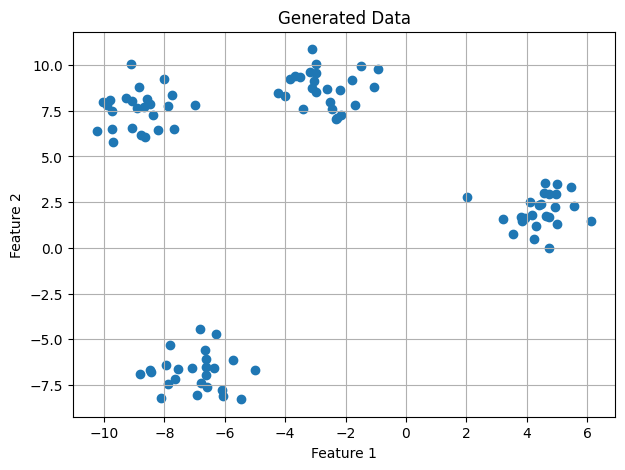

In [10]:

plt.figure(figsize=(7, 5))
plt.scatter(blob_data["feature_1"], blob_data["feature_2"])
plt.title("Generated Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()



## 23. Vẽ dendrogram cho dữ liệu lớn hơn

Lưu ý:

> Với dữ liệu lớn, dendrogram có thể khó nhìn vì có quá nhiều điểm.


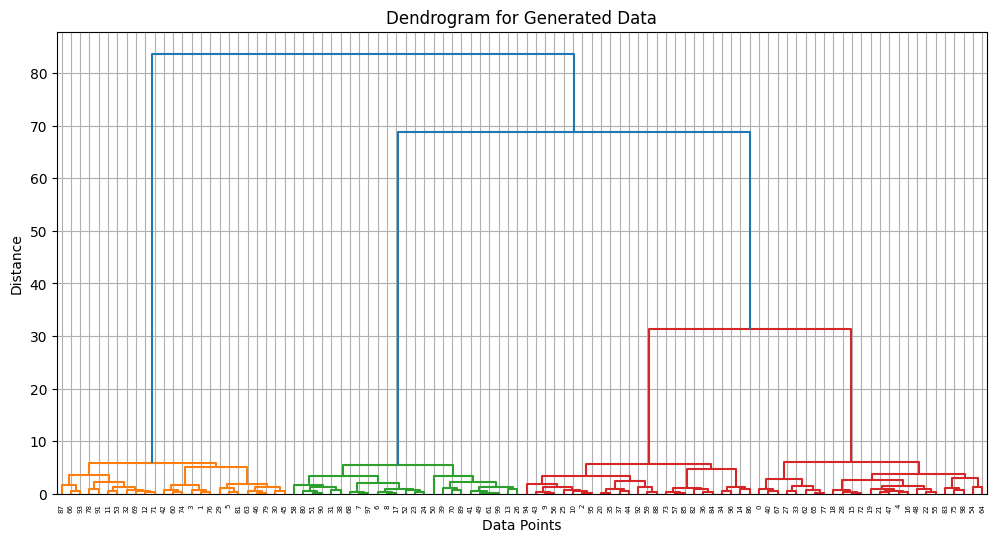

In [11]:

linked_blob = linkage(blob_data, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked_blob)
plt.title("Dendrogram for Generated Data")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()



## 24. Train model với 4 cụm

Vì dữ liệu được tạo từ 4 tâm cụm, ta thử chọn:

```python
n_clusters = 4
```


In [12]:

model_blob = AgglomerativeClustering(n_clusters=4, linkage="ward")
blob_data["cluster"] = model_blob.fit_predict(blob_data)

blob_data.head()


,feature_1,feature_2,cluster
0,-9.685121,5.808676,0
1,-6.066110,-8.110974,1
2,-2.978672,9.556846,3
3,-5.476833,-8.281961,1
4,-8.480540,7.884307,0


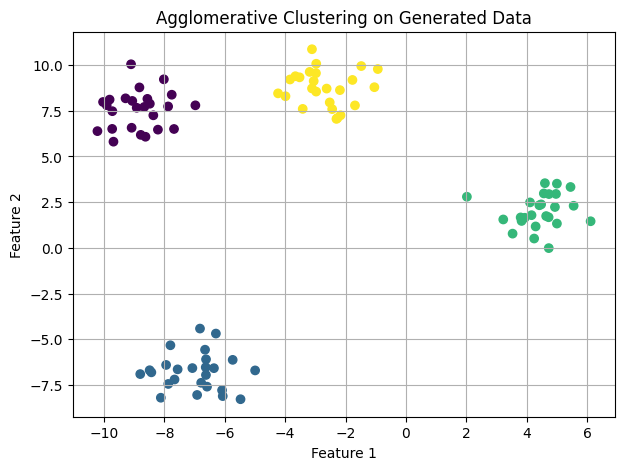

In [13]:

plt.figure(figsize=(7, 5))
plt.scatter(blob_data["feature_1"], blob_data["feature_2"], c=blob_data["cluster"])
plt.title("Agglomerative Clustering on Generated Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()



## 25. So sánh Hierarchical Clustering với K-means

| Tiêu chí | K-means | Hierarchical Clustering |
|---|---|---|
| Cần chọn số cụm trước? | Có | Không bắt buộc lúc đầu |
| Kết quả chính | Cluster labels | Dendrogram + cluster labels |
| Cách hoạt động | Tối ưu centroid | Gộp/tách cụm theo khoảng cách |
| Tốc độ với data lớn | Nhanh hơn | Chậm hơn |
| Dễ giải thích | Khá dễ | Rất trực quan bằng dendrogram |
| Phù hợp khi chưa biết K? | Cần Elbow/Silhouette | Có thể nhìn dendrogram |
| Nhạy với scale dữ liệu | Có | Có |

Tóm gọn:

```text
K-means:
Chọn K trước → thuật toán chia cụm.

Hierarchical Clustering:
Xây cây trước → nhìn dendrogram → chọn số cụm sau.
```



## 26. Ưu điểm và nhược điểm

### Ưu điểm

- Không bắt buộc chọn số cụm ngay từ đầu.
- Dendrogram giúp giải thích quá trình phân cụm rất trực quan.
- Có thể phát hiện cấu trúc phân cấp trong dữ liệu.
- Phù hợp với dữ liệu nhỏ hoặc trung bình.

### Nhược điểm

- Chậm với dataset lớn.
- Nhạy với scale dữ liệu.
- Nhạy với outlier.
- Khi đã gộp cụm thì không quay lại sửa quyết định trước đó.



## 27. Khi nào nên dùng Hierarchical Clustering?

Nên dùng khi:

- Muốn hiểu quan hệ phân cấp giữa các điểm dữ liệu.
- Chưa chắc nên chọn bao nhiêu cụm.
- Dataset không quá lớn.
- Muốn trình bày kết quả bằng dendrogram.
- Làm customer segmentation, document clustering, gene clustering, product grouping.

Không nên dùng khi:

- Dataset quá lớn.
- Cần tốc độ rất nhanh.
- Dữ liệu có quá nhiều noise/outlier.
- Số chiều quá lớn nhưng chưa giảm chiều hoặc xử lý dữ liệu.



## 28. Pipeline chuẩn khi làm Hierarchical Clustering

Một pipeline cơ bản:

```text
1. Load data
2. Chọn feature
3. Xử lý missing values nếu có
4. Scale dữ liệu
5. Vẽ dendrogram
6. Chọn số cụm
7. Train AgglomerativeClustering
8. Gán cluster label
9. Visualize kết quả
10. Giải thích ý nghĩa từng cụm
```



## 29. Bài tập tự luyện

### Bài 1

Tạo dataset khách hàng gồm các cột:

- `age`
- `income`
- `spending_score`

Sau đó:

1. Scale dữ liệu.
2. Vẽ dendrogram.
3. Chọn số cụm phù hợp.
4. Train `AgglomerativeClustering`.
5. Visualize kết quả nếu chọn được 2 feature để vẽ.

### Bài 2

Thử thay đổi linkage:

```python
linkage="single"
linkage="complete"
linkage="average"
linkage="ward"
```

Sau đó so sánh dendrogram.

### Bài 3

Giải thích bằng lời:

```text
Vì sao Hierarchical Clustering không cần chọn K ngay từ đầu,
nhưng cuối cùng vẫn cần chọn số cụm?
```



## 30. Code mẫu cho bài tập

Bạn có thể dùng đoạn code dưới đây làm khung.


In [ ]:

# Example exercise dataset

exercise_data = pd.DataFrame({
    "age": [20, 22, 25, 35, 37, 40, 55, 58, 60, 62],
    "income": [2000, 2200, 2500, 5000, 5200, 5500, 9000, 9200, 9500, 9800],
    "spending_score": [80, 85, 78, 50, 48, 52, 20, 18, 22, 19]
})

exercise_data


In [ ]:

# Select features
X_exercise = exercise_data[["age", "income", "spending_score"]]

# Scale features
scaler = StandardScaler()
X_exercise_scaled = scaler.fit_transform(X_exercise)

# Dendrogram
linked_exercise = linkage(X_exercise_scaled, method="ward")

plt.figure(figsize=(9, 5))
dendrogram(linked_exercise)
plt.title("Exercise Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()


In [ ]:

# Train model
exercise_model = AgglomerativeClustering(n_clusters=3, linkage="ward")
exercise_data["cluster"] = exercise_model.fit_predict(X_exercise_scaled)

exercise_data


In [ ]:

# Visualize using income and spending_score
plt.figure(figsize=(7, 5))
plt.scatter(
    exercise_data["income"], 
    exercise_data["spending_score"], 
    c=exercise_data["cluster"]
)

plt.title("Exercise Clustering Result")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.grid(True)
plt.show()



## 31. Tóm tắt cần nhớ

Những ý quan trọng nhất:

```text
Hierarchical Clustering là thuật toán phân cụm không giám sát.

Nó tạo ra cấu trúc phân cấp giữa các điểm dữ liệu.

Agglomerative Clustering là loại phổ biến nhất:
mỗi điểm là một cụm riêng → gộp dần các cụm gần nhau.

Dendrogram giúp quan sát quá trình gộp cụm và chọn số cụm.

Linkage method quyết định cách đo khoảng cách giữa các cụm.

Các linkage phổ biến:
single, complete, average, ward.

Dữ liệu nên được scale trước khi clustering.

Hierarchical Clustering dễ giải thích nhưng chậm với dữ liệu lớn.
```

Câu nhớ nhanh:

> **Hierarchical Clustering = gom nhóm theo tầng, nhìn dendrogram để chọn số cụm.**
